In [13]:
import os, glob, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
from natsort import natsorted

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── paths ──
BASE_PATH = r'C:\Users\danie\Desktop\Tropical Cyclones'
PATH_1D   = os.path.join(BASE_PATH, 'TCND_Data1D', 'Data1D')
PATH_3D = os.path.join(BASE_PATH, 'TCND_Data3D_WP', 'WP')
PATH_ENV  = os.path.join(BASE_PATH, 'TCND_Env-Data', 'Env-Data')
SAVE_DIR  = os.path.join(BASE_PATH, 'classification', 'saved_models')
os.makedirs(SAVE_DIR, exist_ok=True)

AREA = 'WP'  # Western Pacific (only basin with Data_3d)

# verify paths
for p, name in [(PATH_1D, 'Data_1d'), (PATH_3D, 'Data_3d'), (PATH_ENV, 'Env-Data')]:
    print(f'{name}: {"OK" if os.path.isdir(p) else "MISSING"} — {p}')

# ── Global normalization for 4 physics-motivated channels ──
# SST (thermodynamic fuel), z@500hPa (steering flow),
# u@200hPa (upper outflow), u@850hPa (boundary layer inflow)
CHANNEL_MEANS = np.array([262.4888, 57228.5285, 1.8846, -0.1519], dtype=np.float32)
CHANNEL_STDS  = np.array([99.7658, 640.2119, 14.9477, 8.4176], dtype=np.float32)
CHANNEL_MEANS_T = torch.from_numpy(CHANNEL_MEANS).view(4, 1, 1)
CHANNEL_STDS_T  = torch.from_numpy(CHANNEL_STDS).view(4, 1, 1)

Using device: cuda
Data_1d: OK — C:\Users\danie\Desktop\Tropical Cyclones\TCND_Data1D\Data1D
Data_3d: OK — C:\Users\danie\Desktop\Tropical Cyclones\TCND_Data3D_WP\WP
Env-Data: OK — C:\Users\danie\Desktop\Tropical Cyclones\TCND_Env-Data\Env-Data


In [2]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


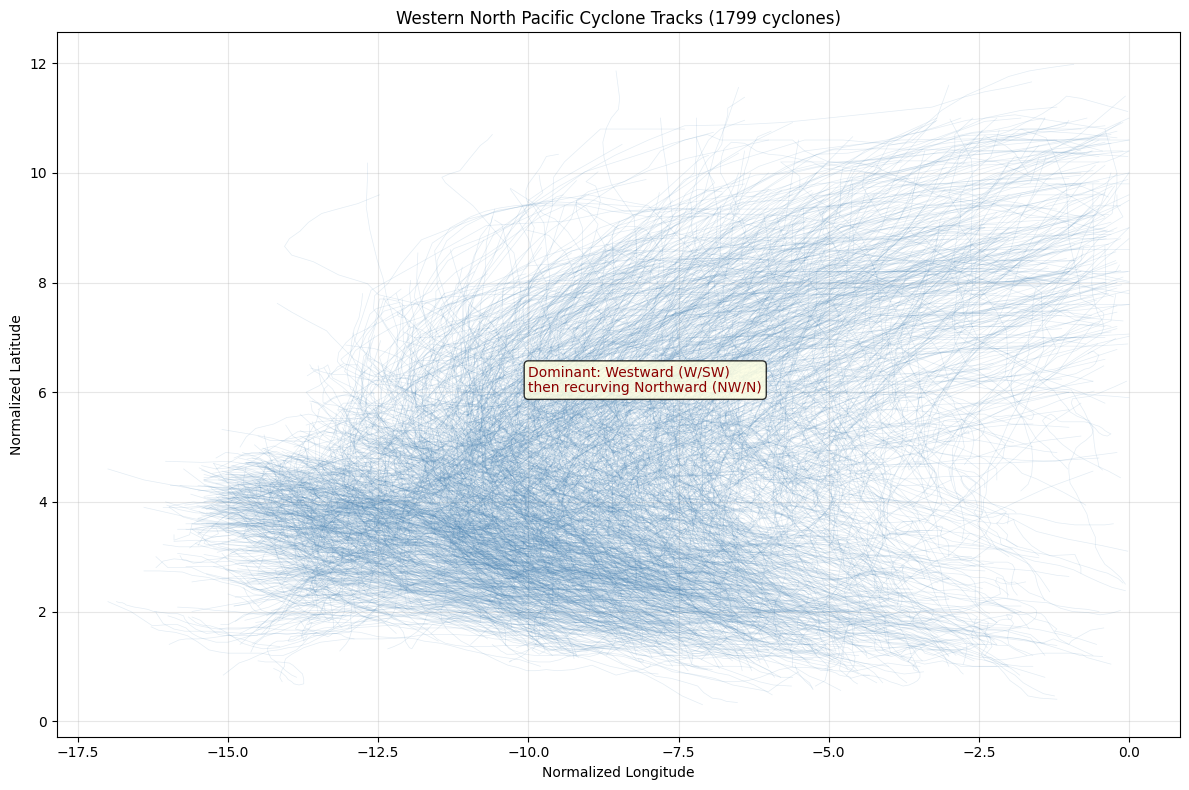

Plotted 1799 cyclone tracks.
Most WP cyclones form in the tropics and move W/SW, then recurve NW/N at higher latitudes.


In [5]:
# ── 1.5a: Cyclone Track Map (Data_1d) ──
# Plot all WP cyclone tracks using normalized coordinates.
# Data_1d stores LON/LAT as normalized values (not raw degrees).
fig, ax = plt.subplots(figsize=(12, 8))

track_count = 0
for split in ['train', 'val', 'test']:
    path = os.path.join(PATH_1D, AREA, split)
    for f in glob.glob(os.path.join(path, '*.txt')):
        df = pd.read_csv(f, delimiter='\t', header=None,
                         names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
        ax.plot(df['LON'].values, df['LAT'].values, alpha=0.15, linewidth=0.5, color='steelblue')
        track_count += 1

ax.set_xlabel('Normalized Longitude')
ax.set_ylabel('Normalized Latitude')
ax.set_title(f'Western North Pacific Cyclone Tracks ({track_count} cyclones)')
ax.grid(True, alpha=0.3)

# Add annotation explaining the dominant movement
ax.annotate('Dominant: Westward (W/SW)\nthen recurving Northward (NW/N)',
            xy=(-10, 6), fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'track_map.png'), dpi=150)
plt.show()
print(f'Plotted {track_count} cyclone tracks.')
print('Most WP cyclones form in the tropics and move W/SW, then recurve NW/N at higher latitudes.')

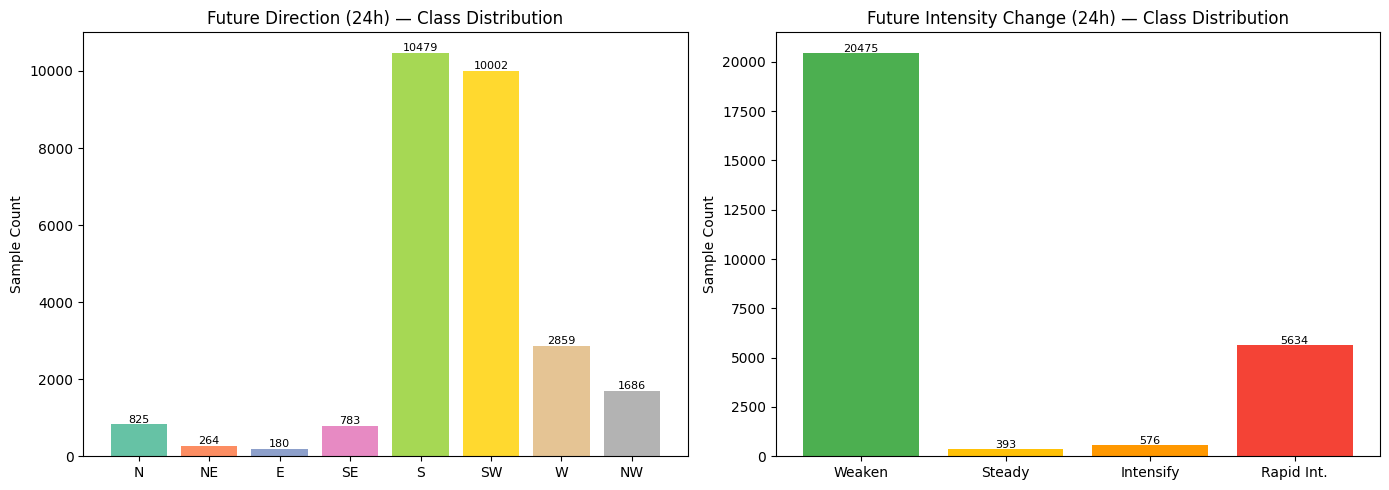

Direction: S and SW dominate — most WP cyclones move westward.
Intensity: Weaken and Intensify are common; Steady and Rapid Int. are rare.


In [6]:
# ── 1.5b: Class Distributions (from Env-Data) ──
# Shows why some directions are harder to predict — severe class imbalance.
dir_counts = np.zeros(8)
int_counts = np.zeros(4)

for split in ['train', 'val', 'test']:
    env_base = os.path.join(PATH_ENV, AREA)
    for year_dir in sorted(glob.glob(os.path.join(env_base, '*'))):
        for cyc_dir in glob.glob(os.path.join(year_dir, '*')):
            for npy_f in glob.glob(os.path.join(cyc_dir, '*.npy'))[:5]:  # sample per cyclone
                try:
                    d = np.load(npy_f, allow_pickle=True).item()
                    dl = d.get('future_direction24', None)
                    il = d.get('future_inte_change24', None)
                    if dl is not None and 0 <= int(dl) < 8:
                        dir_counts[int(dl)] += 1
                    if il is not None and 0 <= int(il) < 4:
                        int_counts[int(il)] += 1
                except:
                    pass

DIR_NAMES = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_NAMES = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Direction distribution
colors_dir = plt.cm.Set2(np.linspace(0, 1, 8))
bars1 = ax1.bar(DIR_NAMES, dir_counts, color=colors_dir)
ax1.set_title('Future Direction (24h) — Class Distribution')
ax1.set_ylabel('Sample Count')
for bar, count in zip(bars1, dir_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(count)}', ha='center', fontsize=8)

# Intensity distribution
colors_int = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars2 = ax2.bar(INT_NAMES, int_counts, color=colors_int)
ax2.set_title('Future Intensity Change (24h) — Class Distribution')
ax2.set_ylabel('Sample Count')
for bar, count in zip(bars2, int_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(count)}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distributions.png'), dpi=150)
plt.show()
print(f'Direction: S and SW dominate — most WP cyclones move westward.')
print(f'Intensity: Weaken and Intensify are common; Steady and Rapid Int. are rare.')

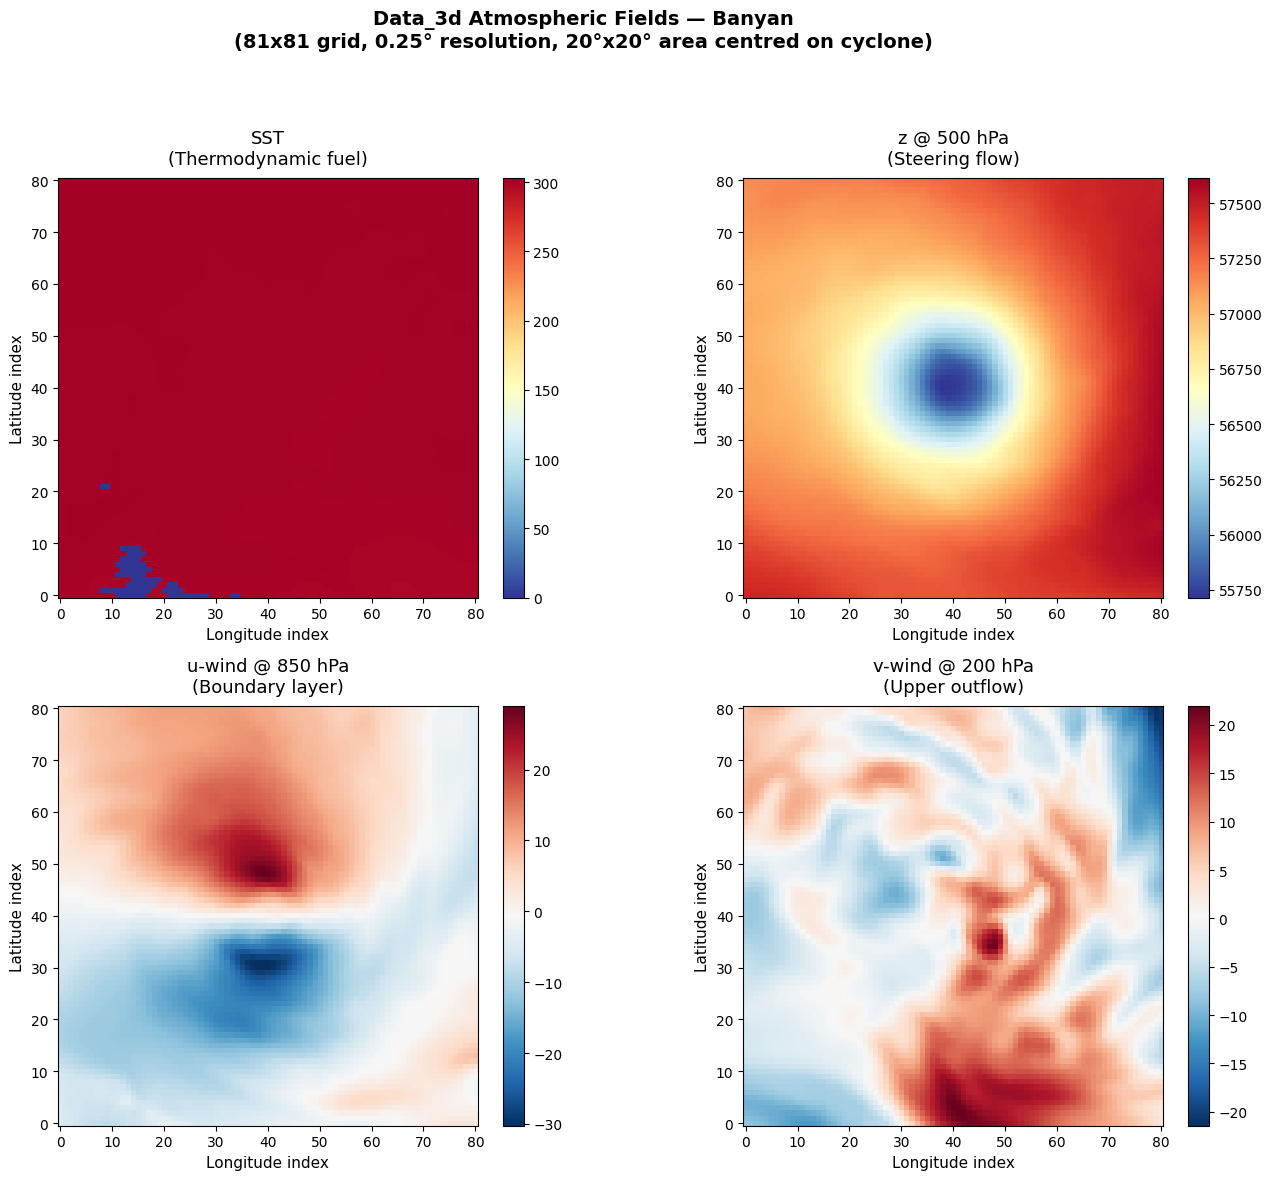

Each 81x81 grid covers a 20°x20° area centred on the cyclone.
The CNN processes all 13 channels simultaneously to extract atmospheric features.


In [7]:
# ── 1.5c: Sample Data_3d Atmospheric Fields ──
# Visualize what the CNN "sees" — one timestep of a cyclone.
sample_nc = glob.glob(os.path.join(PATH_3D, '2005', '*', '*.nc'))
if not sample_nc:
    sample_nc = glob.glob(os.path.join(PATH_3D, '2005', '*', '*_cache.npy'))

if sample_nc:
    nc_path = sample_nc[len(sample_nc)//2]  # pick a middle file
    if nc_path.endswith('.npy'):
        frame = np.load(nc_path)
    else:
        # Load directly without caching (Kaggle input is read-only)
        with ncDataset(nc_path) as nc:
            sst = np.ma.filled(nc.variables['sst'][:], fill_value=0.0)
            z   = np.ma.filled(nc.variables['z'][0, :, :, :], fill_value=0.0)
            u   = np.ma.filled(nc.variables['u'][0, :, :, :], fill_value=0.0)
            v   = np.ma.filled(nc.variables['v'][0, :, :, :], fill_value=0.0)
        frame = np.concatenate([sst[np.newaxis], z, u, v], axis=0).astype(np.float32)
    
    # Show 4 key channels: SST, z@500 (steering), u@850 (boundary wind), v@200 (outflow)
    key_channels = [0, 2, 7, 9]
    key_names = ['SST\n(Thermodynamic fuel)', 'z @ 500 hPa\n(Steering flow)',
                 'u-wind @ 850 hPa\n(Boundary layer)', 'v-wind @ 200 hPa\n(Upper outflow)']
    cmaps = ['RdYlBu_r', 'RdYlBu_r', 'RdBu_r', 'RdBu_r']
    
    cyclone_name = os.path.basename(os.path.dirname(nc_path))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Data_3d Atmospheric Fields — {cyclone_name}\n(81x81 grid, 0.25° resolution, 20°x20° area centred on cyclone)',
                 fontsize=14, fontweight='bold')
    
    for ax, ch_idx, name, cmap in zip(axes.flatten(), key_channels, key_names, cmaps):
        im = ax.imshow(frame[ch_idx], cmap=cmap, origin='lower', aspect='equal')
        ax.set_title(name, fontsize=13, pad=10)
        ax.set_xlabel('Longitude index', fontsize=11)
        ax.set_ylabel('Latitude index', fontsize=11)
        ax.tick_params(labelsize=10)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=10)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(os.path.join(SAVE_DIR, 'sample_data3d.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print('Each 81x81 grid covers a 20°x20° area centred on the cyclone.')
    print('The CNN processes all 13 channels simultaneously to extract atmospheric features.')
else:
    print('No Data_3d files found for visualization.')

2. Dataset Classes

In [14]:
# ── Constants for Env-Data vector assembly ──
# When an Env-Data field is -1 (not enough history), we replace with zeros.
ENV_VECTOR_DIM = 87  # area(6)+intensity_class(6)+month(12)+location_long(36)+location_lat(12)+wind(1)+move_velocity(1)+hist_dir12(8)+hist_dir24(8)+hist_inte24(4) - but subtract location tuple = 87 total
# Actual breakdown: 6+6+12+36+12+1+1+8+8+4 = 94 ... let's compute it precisely below.

def _env_to_vector(env_dict):
    """Convert an Env-Data dict to a fixed-size float vector.
    
    Handles the -1 sentinel for missing history by replacing with zeros.
    Returns: np.array of shape (ENV_VEC_DIM,)
    """
    parts = []
    
    # Cyclone attributes
    parts.append(np.asarray(env_dict['area'], dtype=np.float32))            # (6,)
    parts.append(np.asarray(env_dict['intensity_class'], dtype=np.float32)) # (6,)
    parts.append(np.asarray(env_dict['month'], dtype=np.float32))           # (12,)
    
    # Location (one-hot encoded)
    parts.append(np.asarray(env_dict['location_long'], dtype=np.float32))   # (36,)
    parts.append(np.asarray(env_dict['location_lat'], dtype=np.float32))    # (12,)
    
    # Scalars
    wind = float(env_dict['wind']) if not isinstance(env_dict['wind'], np.ndarray) else float(env_dict['wind'])
    mv = float(env_dict['move_velocity']) if not isinstance(env_dict['move_velocity'], np.ndarray) else float(env_dict['move_velocity'])
    parts.append(np.array([wind, mv], dtype=np.float32))                    # (2,)
    
    # History (may be -1 sentinel → zeros)
    for key, size in [('history_direction12', 8), ('history_direction24', 8), ('history_inte_change24', 4)]:
        val = env_dict[key]
        if isinstance(val, (int, float, np.integer)) and val == -1:
            parts.append(np.zeros(size, dtype=np.float32))
        else:
            parts.append(np.asarray(val, dtype=np.float32).flatten()[:size])
    
    return np.concatenate(parts)  # total: 6+6+12+36+12+2+8+8+4 = 94

ENV_VEC_DIM = 94  # verified above
print(f'Env-Data vector dimension: {ENV_VEC_DIM}')

Env-Data vector dimension: 94


In [15]:
def _nc_exists(nc_path):
    """Check if a NetCDF file or its cached .npy version exists."""
    return os.path.exists(nc_path) or os.path.exists(nc_path.replace('.nc', '_cache.npy'))


def _load_nc_frame(nc_path):
    cache_path = os.path.join('/kaggle/working', 'nc_cache',
                              os.path.relpath(nc_path, PATH_3D).replace('.nc', '_cache.npy'))
    if os.path.exists(cache_path):
        return np.load(cache_path)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with ncDataset(nc_path) as nc:
        sst  = np.ma.filled(nc.variables['sst'][:, :], fill_value=0.0)      # (81,81)
        z500 = np.ma.filled(nc.variables['z'][0, 1, :, :], fill_value=0.0)  # 500hPa
        u200 = np.ma.filled(nc.variables['u'][0, 0, :, :], fill_value=0.0)  # 200hPa
        u850 = np.ma.filled(nc.variables['u'][0, 2, :, :], fill_value=0.0)  # 850hPa
    frame = np.stack([sst, z500, u200, u850], axis=0).astype(np.float32)   # (4, 81, 81)
    np.save(cache_path, frame)
    return frame


class CycloneDataset(Dataset):
    """Multi-modal dataset for TC prediction.
    
    Modes (controlled by `use_3d` and `use_env`):
      - Data_1d always loaded  (LON, LAT, P, W per timestep)
      - Env-Data optionally loaded (94-dim vector per timestep)
      - Data_3d optionally loaded  (13 channels x 81 x 81 per timestep)
    
    Labels come from Env-Data: future_direction24 (8-class) and future_inte_change24 (4-class).
    
    `splits` can be a list of directories to scan (e.g. ['train', 'val']) to
    combine data from multiple pre-split folders when doing temporal splitting.
    """

    # Data_3d channels: sst(1) + z(4) + u(4) + v(4) = 13
    NUM_3D_CHANNELS = 4

    def __init__(self, area=AREA, splits='train', target_years=None,
                 seq_len=5, use_env=False, use_3d=False):
        self.seq_len = seq_len
        self.use_env = use_env
        self.use_3d = use_3d
        self.samples = []

        # Support scanning multiple split directories
        if isinstance(splits, str):
            splits = [splits]

        files = []
        for split in splits:
            path_1d = os.path.join(PATH_1D, area, split)
            files.extend(natsorted(glob.glob(os.path.join(path_1d, '*.txt'))))

        for f in files:
            # Parse year from filename (e.g. WP2018BSTMANGKHUT.txt -> 2018)
            basename = os.path.basename(f)
            try:
                year = int(basename[2:6])
            except (ValueError, IndexError):
                continue
            if target_years and year not in target_years:
                continue

            df = pd.read_csv(f, delimiter='\t', header=None,
                             names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
            if len(df) < seq_len + 1:
                continue

            cyclone_name = str(df.iloc[0]['Name']).strip()

            for i in range(seq_len - 1, len(df) - 1):
                curr_seq = df.iloc[i - seq_len + 1: i + 1]
                timestamps = [str(int(row['TIME'])) for _, row in curr_seq.iterrows()]
                last_ts = timestamps[-1]

                # ── Labels from Env-Data ──
                env_path_last = os.path.join(PATH_ENV, area, str(year),
                                             cyclone_name, f'{last_ts}.npy')
                if not os.path.exists(env_path_last):
                    continue
                env_last = np.load(env_path_last, allow_pickle=True).item()

                dir_label = env_last.get('future_direction24', None)
                int_label = env_last.get('future_inte_change24', None)
                if dir_label is None or int_label is None:
                    continue
                dir_label = int(dir_label)
                int_label = int(int_label)
                if not (0 <= dir_label < 8 and 0 <= int_label < 4):
                    continue

                # ── Env-Data paths (one per timestep) ──
                env_paths = None
                if use_env:
                    env_paths = []
                    valid = True
                    for ts in timestamps:
                        ep = os.path.join(PATH_ENV, area, str(year),
                                         cyclone_name, f'{ts}.npy')
                        if not os.path.exists(ep):
                            valid = False
                            break
                        env_paths.append(ep)
                    if not valid:
                        continue

                # ── Data_3d paths (one per timestep) ──
                nc_paths = None
                if use_3d:
                    nc_paths = []
                    valid = True
                    for ts in timestamps:
                        nc = os.path.join(PATH_3D, str(year), cyclone_name,
                                         f'TCND_{cyclone_name}_{ts}_sst_z_u_v.nc')
                        if not _nc_exists(nc):
                            valid = False
                            break
                        nc_paths.append(nc)
                    if not valid:
                        continue

                self.samples.append({
                    'feat1d': curr_seq[['LON', 'LAT', 'P', 'W']].values.astype(np.float32),
                    'env_paths': env_paths,
                    'nc_paths': nc_paths,
                    'dir_label': dir_label,
                    'int_label': int_label,
                })

        print(f'[{area}/{splits}] {len(self.samples)} samples '
              f'(env={use_env}, 3d={use_3d}, years={target_years})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # 1D features — always present
        feat1d = torch.from_numpy(s['feat1d'])  # (seq_len, 4)

        # Env-Data
        if self.use_env:
            env_vecs = []
            for ep in s['env_paths']:
                d = np.load(ep, allow_pickle=True).item()
                env_vecs.append(_env_to_vector(d))
            env_feat = torch.from_numpy(np.stack(env_vecs))  # (seq_len, 94)
        else:
            env_feat = torch.zeros(feat1d.shape[0], ENV_VEC_DIM)

        # Data_3d — cached loading + global normalization
        if self.use_3d:
            spatial_list = [_load_nc_frame(p) for p in s['nc_paths']]
            spatial = torch.from_numpy(np.stack(spatial_list))  # (seq,13,81,81)
            # Global channel-wise normalization using pre-computed training stats.
            spatial = (spatial - CHANNEL_MEANS_T) / CHANNEL_STDS_T
        else:
            spatial = torch.zeros(feat1d.shape[0], self.NUM_3D_CHANNELS, 81, 81)

        return (feat1d, env_feat, spatial,
                torch.tensor(s['dir_label']).long(),
                torch.tensor(s['int_label']).long())

### 3. Model Defintions ###

In [16]:
class SpatialEncoder(nn.Module):
    def __init__(self, in_channels=4, feat_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                          # 40x40
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                          # 20x20
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),             # 2x2
            nn.Flatten(),                             # 512
            nn.Linear(512, feat_dim),
            nn.ReLU(),
        )


    def forward(self, x):
        return self.net(x)


class CycloneModel(nn.Module):
    """Unified model supporting three modes:
       - baseline:  1d only
       - env:       1d + env-data
       - full:      1d + env-data + 3d
       
    
    Dual prediction heads: direction (8-class) and intensity change (4-class).
    """

    def __init__(self, use_env=False, use_3d=False,
                 hidden_dim=256, spatial_feat_dim=512):
        super().__init__()
        self.use_env = use_env
        self.use_3d = use_3d

        # 1D trajectory embedding
        self.traj_embed = nn.Sequential(
            nn.Linear(4, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
        )
        input_dim = 64

        # Env-Data embedding
        if use_env:
            self.env_embed = nn.Sequential(
                nn.Linear(ENV_VEC_DIM, 128),
                nn.LayerNorm(128),
                nn.ReLU(),
            )
            input_dim += 128

        # Spatial encoder
        if use_3d:
            self.spatial_enc = SpatialEncoder(in_channels=4,
                                             feat_dim=spatial_feat_dim)
            input_dim += spatial_feat_dim

        # Temporal model
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=2, batch_first=True, dropout=0.2)

        # Dual heads
        self.dir_head = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 8),
        )
        self.int_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, 4),
        )

    def forward(self, feat1d, env_feat, spatial):
        B, T, _ = feat1d.shape

        parts = [self.traj_embed(feat1d)]  # (B, T, 64)

        if self.use_env:
            parts.append(self.env_embed(env_feat))  # (B, T, 128)

        if self.use_3d:
            # spatial: (B, T, C, H, W)
            C, H, W = spatial.shape[2], spatial.shape[3], spatial.shape[4]
            sp_flat = spatial.reshape(B * T, C, H, W)
            sp_feat = self.spatial_enc(sp_flat).reshape(B, T, -1)  # (B, T, 512)
            parts.append(sp_feat)

        combined = torch.cat(parts, dim=-1)
        _, hn = self.gru(combined)  # hn: (num_layers, B, hidden_dim)
        h = hn[-1]  # (B, hidden_dim)

        return self.dir_head(h), self.int_head(h)

### 4. Training & Evaluation Utilities ###

In [17]:
def train_one_epoch(model, loader, optimizer, dir_criterion, int_criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for feat1d, env_feat, spatial, dir_y, int_y in loader:
        feat1d  = feat1d.to(device)
        env_feat = env_feat.to(device)
        spatial = spatial.to(device)
        dir_y   = dir_y.to(device)
        int_y   = int_y.to(device)

        optimizer.zero_grad()
        dir_logits, int_logits = model(feat1d, env_feat, spatial)
        loss = dir_criterion(dir_logits, dir_y) + int_criterion(int_logits, int_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * dir_y.size(0)
        n += dir_y.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, dir_criterion, int_criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    dir_correct, int_correct = 0, 0
    dir_preds, dir_labels = [], []
    int_preds, int_labels = [], []

    for feat1d, env_feat, spatial, dir_y, int_y in loader:
        feat1d  = feat1d.to(device)
        env_feat = env_feat.to(device)
        spatial = spatial.to(device)
        dir_y   = dir_y.to(device)
        int_y   = int_y.to(device)

        dir_logits, int_logits = model(feat1d, env_feat, spatial)
        loss = dir_criterion(dir_logits, dir_y) + int_criterion(int_logits, int_y)

        dp = dir_logits.argmax(dim=1)
        ip = int_logits.argmax(dim=1)
        dir_correct += (dp == dir_y).sum().item()
        int_correct += (ip == int_y).sum().item()

        dir_preds.extend(dp.cpu().tolist())
        dir_labels.extend(dir_y.cpu().tolist())
        int_preds.extend(ip.cpu().tolist())
        int_labels.extend(int_y.cpu().tolist())

        total_loss += loss.item() * dir_y.size(0)
        n += dir_y.size(0)

    return {
        'loss': total_loss / n,
        'dir_acc': dir_correct / n,
        'int_acc': int_correct / n,
        'dir_preds': dir_preds, 'dir_labels': dir_labels,
        'int_preds': int_preds, 'int_labels': int_labels,
    }

In [18]:
def run_experiment(name, use_env, use_3d, train_years, val_years, test_years,
                   train_splits=['train'], val_splits=['val'], test_splits=['test'],
                   epochs=80, batch_size=32, lr=5e-4, patience=12):
    """Train a model variant and return results dict."""
    print(f'\n{"="*60}')
    print(f'Experiment: {name}')
    print(f'  use_env={use_env}, use_3d={use_3d}')
    print(f'  train={train_years} from {train_splits}')
    print(f'  val={val_years} from {val_splits}')
    print(f'  test={test_years} from {test_splits}')
    print(f'{"="*60}')

    # Datasets
    train_ds = CycloneDataset(splits=train_splits, target_years=train_years,
                              use_env=use_env, use_3d=use_3d)
    val_ds   = CycloneDataset(splits=val_splits, target_years=val_years,
                              use_env=use_env, use_3d=use_3d)
    test_ds  = CycloneDataset(splits=test_splits, target_years=test_years,
                              use_env=use_env, use_3d=use_3d)

    if len(train_ds) == 0:
        print('ERROR: No training samples found. Skipping.')
        return None

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=0) if len(val_ds) > 0 else None
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=0) if len(test_ds) > 0 else None

    # Model
    model = CycloneModel(use_env=use_env, use_3d=use_3d).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable parameters: {total_params:,}')

    # Class-weighted loss to handle imbalance
    # Compute class frequencies from training data
    dir_counts = np.zeros(8)
    int_counts = np.zeros(4)
    for s in train_ds.samples:
        dir_counts[s['dir_label']] += 1
        int_counts[s['int_label']] += 1
    dir_weights = torch.from_numpy(dir_counts.sum() / (8 * dir_counts + 1)).float().to(DEVICE)
    int_weights = torch.from_numpy(int_counts.sum() / (4 * int_counts + 1)).float().to(DEVICE)
    print(f'  Direction class weights: {dir_weights.cpu().numpy().round(2)}')
    print(f'  Intensity class weights: {int_weights.cpu().numpy().round(2)}')

    dir_criterion = nn.CrossEntropyLoss(weight=dir_weights, label_smoothing=0.1)
    int_criterion = nn.CrossEntropyLoss(weight=int_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Training loop with early stopping
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dir_acc': [], 'val_int_acc': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     dir_criterion, int_criterion, DEVICE)
        scheduler.step()
        history['train_loss'].append(train_loss)

        # Validation
        if val_loader is not None:
            val_res = evaluate(model, val_loader, dir_criterion, int_criterion, DEVICE)
            history['val_loss'].append(val_res['loss'])
            history['val_dir_acc'].append(val_res['dir_acc'])
            history['val_int_acc'].append(val_res['int_acc'])

            if val_res['loss'] < best_val_loss:
                best_val_loss = val_res['loss']
                epochs_no_improve = 0
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, f'{name}_best.pth'))
            else:
                epochs_no_improve += 1

            if epoch % 5 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | '
                      f'train_loss={train_loss:.4f} | '
                      f'val_loss={val_res["loss"]:.4f} | '
                      f'dir_acc={val_res["dir_acc"]:.3f} | '
                      f'int_acc={val_res["int_acc"]:.3f} | '
                      f'lr={optimizer.param_groups[0]["lr"]:.2e}')

            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break
        else:
            if epoch % 5 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f}')

    # Load best model for testing
    best_path = os.path.join(SAVE_DIR, f'{name}_best.pth')
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, weights_only=True))
        print(f'  Loaded best model from {best_path}')

    # Test evaluation
    test_res = None
    if test_loader is not None:
        test_res = evaluate(model, test_loader, dir_criterion, int_criterion, DEVICE)
        print(f'\n  TEST — dir_acc={test_res["dir_acc"]:.3f}, '
              f'int_acc={test_res["int_acc"]:.3f}, loss={test_res["loss"]:.4f}')

    return {'name': name, 'model': model, 'history': history,
            'test_res': test_res, 'test_ds': test_ds}

In [19]:
decade_results = {}

In [85]:
print('Decade Experiment: 1960s-1970s (train on 1960-1979)')
res = run_experiment(
    name='decade_1960s-1970s', use_env=True, use_3d=True,
    train_years=list(range(1960, 1980)),
    val_years=list(range(1960, 1980)),
    test_years=list(range(2017, 2024)),
    train_splits=['train'], val_splits=[ 'val'], test_splits=['test'],
    epochs=50, batch_size=32, lr=3e-4, patience=7,
)
if res and res['test_res']:
    decade_results['1960s-1970s'] = res['test_res']

Decade Experiment: 1960s-1970s (train on 1960-1979)

Experiment: decade_1960s-1970s
  use_env=True, use_3d=True
  train=[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979] from ['train']
  val=[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979] from ['val']
  test=[2017, 2018, 2019, 2020, 2021, 2022, 2023] from ['test']
[WP/['train']] 11931 samples (env=True, 3d=True, years=[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979])
[WP/['val']] 3009 samples (env=True, 3d=True, years=[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979])
[WP/['test']] 3394 samples (env=True, 3d=True, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
Trainable parameters: 1,553,708
  Direction class weights: [ 1.7  12.52 16.37  5.09  0.45  0

In [86]:
print('Decade Experiment: 1980s-1990s (train on 1980-1999)')
res = run_experiment(
    name='decade_1980s-1990s', use_env=True, use_3d=True,
    train_years=list(range(1980, 2000)),
    val_years=list(range(1980, 2000)),
    test_years=list(range(2017, 2024)),
    train_splits=['train'], val_splits=[ 'val'], test_splits=['test'],
    epochs=50, batch_size=32, lr=3e-4, patience=7,
)

if res and res['test_res']:
    decade_results['1980s-1990s'] = res['test_res']

Decade Experiment: 1980s-1990s (train on 1980-1999)

Experiment: decade_1980s-1990s
  use_env=True, use_3d=True
  train=[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999] from ['train']
  val=[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999] from ['val']
  test=[2017, 2018, 2019, 2020, 2021, 2022, 2023] from ['test']
[WP/['train']] 9405 samples (env=True, 3d=True, years=[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999])
[WP/['val']] 2529 samples (env=True, 3d=True, years=[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999])
[WP/['test']] 3394 samples (env=True, 3d=True, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
Trainable parameters: 1,553,708
  Direction class weights: [ 2.78 12.36 17.78  4.5   0.46  0.

In [10]:
print('Decade Experiment: 2000s (Consistent Train/Val Random Split on 2000-2012)')

res = run_experiment(
    name='decade_2000s_consistent', 
    use_env=True, 
    use_3d=True,
    
    # 1. FIXED: Exact same years for both to ensure it learns the 2000s climate perfectly
    train_years=list(range(2000, 2013)), 
    val_years=list(range(2000, 2013)),   
    
    test_years=list(range(2017, 2024)),
    
    # 2. FIXED: Pulling from distinct directories so storms don't mix!
    train_splits=['train'], 
    val_splits=['val'], 
    test_splits=['test'],
    
    epochs=50, batch_size=32, lr=3e-4, patience=7,
)

Decade Experiment: 2000s (Consistent Train/Val Random Split on 2000-2012)

Experiment: decade_2000s_consistent
  use_env=True, use_3d=True
  train=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012] from ['train']
  val=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012] from ['val']
  test=[2017, 2018, 2019, 2020, 2021, 2022, 2023] from ['test']
[WP/['train']] 5360 samples (env=True, 3d=True, years=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012])
[WP/['val']] 1521 samples (env=True, 3d=True, years=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012])
[WP/['test']] 3394 samples (env=True, 3d=True, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
Trainable parameters: 1,553,708
  Direction class weights: [ 2.95 13.64 18.55  4.96  0.49  0.42  0.74  0.65]
  Intensity class weights: [0.62 4.98 0.65 1.56]
  Epoch   1/50 | train_loss=4.1892 | val_loss=4.1096 | dir_acc=0.428 | int_a

## Decade Experiment — Evaluation & Comparison

Load saved decade model weights and evaluate on the test set (2017–2023).
Compare direction and intensity accuracy across training eras to identify climate change signals.

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# ── Load and evaluate saved decade models ──
DIR_LABELS = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_LABELS = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

TEST_YEARS = list(range(2017, 2024))

decade_configs = {
    '1960s-1970s': list(range(1960, 1980)),
    '1980s-1990s': list(range(1980, 2000)),
    '2000s':       list(range(2000, 2013)),
}

decade_eval = {}

# Build test dataset once (same for all decade models)
test_ds = CycloneDataset(splits=['test'], target_years=TEST_YEARS,
                         use_env=True, use_3d=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

# Dummy criteria for evaluate() — weights don't affect accuracy, only loss
dir_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
int_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for label, train_yrs in decade_configs.items():
    # Match the saved weight filenames
    if label == '2000s':
        weight_name = 'decade_2000s_best.pth'
    else:
        weight_name = f'decade_{label}_best.pth'
    
    weight_path = os.path.join(SAVE_DIR, weight_name)
    
    if not os.path.exists(weight_path):
        print(f'{label}: weights not found at {weight_path}')
        continue
    
    model = CycloneModel(use_env=True, use_3d=True).to(DEVICE)
    model.load_state_dict(torch.load(weight_path, weights_only=True))
    model.eval()
    
    res = evaluate(model, test_loader, dir_criterion, int_criterion, DEVICE)
    decade_eval[label] = res
    
    print(f'{label} (train {train_yrs[0]}-{train_yrs[-1]}): '
          f'Dir Acc={res["dir_acc"]:.1%} | Int Acc={res["int_acc"]:.1%} | '
          f'Samples: {len(test_ds)}')

print(f'\n{"Era":<20} {"Train Years":<20} {"Dir Acc":>10} {"Int Acc":>10}')
print('-' * 62)
for label, res in decade_eval.items():
    yrs = decade_configs[label]
    print(f'{label:<20} {f"{yrs[0]}-{yrs[-1]}":<20} {res["dir_acc"]:>10.1%} {res["int_acc"]:>10.1%}')

[WP/['test']] 3394 samples (env=True, 3d=True, years=[2017, 2018, 2019, 2020, 2021, 2022, 2023])
1960s-1970s (train 1960-1979): Dir Acc=55.2% | Int Acc=51.3% | Samples: 3394
1980s-1990s (train 1980-1999): Dir Acc=50.4% | Int Acc=56.7% | Samples: 3394
2000s (train 2000-2012): Dir Acc=52.4% | Int Acc=55.4% | Samples: 3394

Era                  Train Years             Dir Acc    Int Acc
--------------------------------------------------------------
1960s-1970s          1960-1979                 55.2%      51.3%
1980s-1990s          1980-1999                 50.4%      56.7%
2000s                2000-2012                 52.4%      55.4%


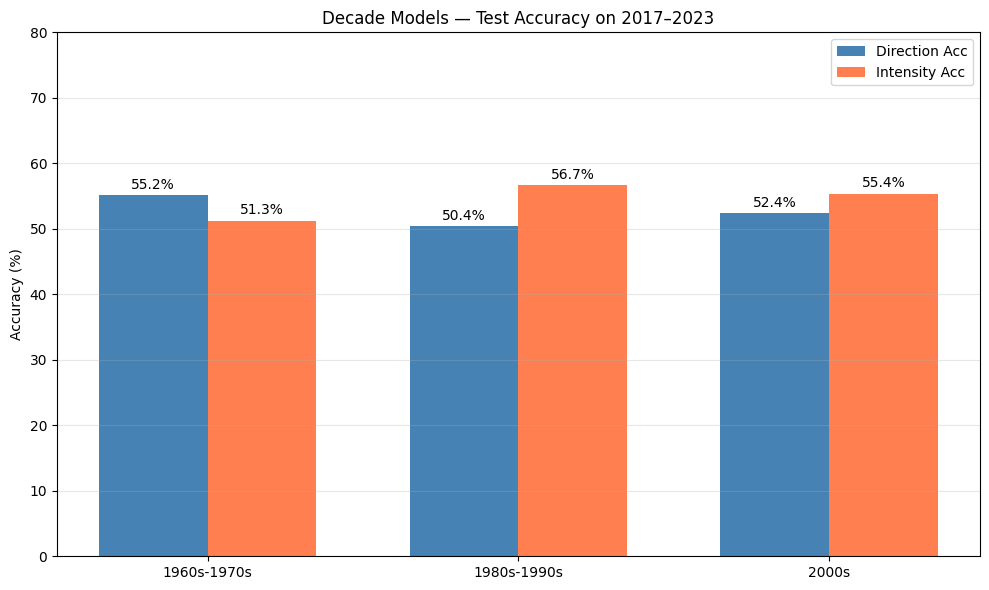

In [21]:
# ── Decade comparison bar chart ──
if decade_eval:
    names = list(decade_eval.keys())
    dir_accs = [decade_eval[n]['dir_acc'] * 100 for n in names]
    int_accs = [decade_eval[n]['int_acc'] * 100 for n in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, dir_accs, width, label='Direction Acc', color='steelblue')
    bars2 = ax.bar(x + width/2, int_accs, width, label='Intensity Acc', color='coral')

    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Decade Models — Test Accuracy on 2017–2023')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.legend()
    ax.set_ylim(0, 80)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'decade_comparison.png'), dpi=150)
    plt.show()

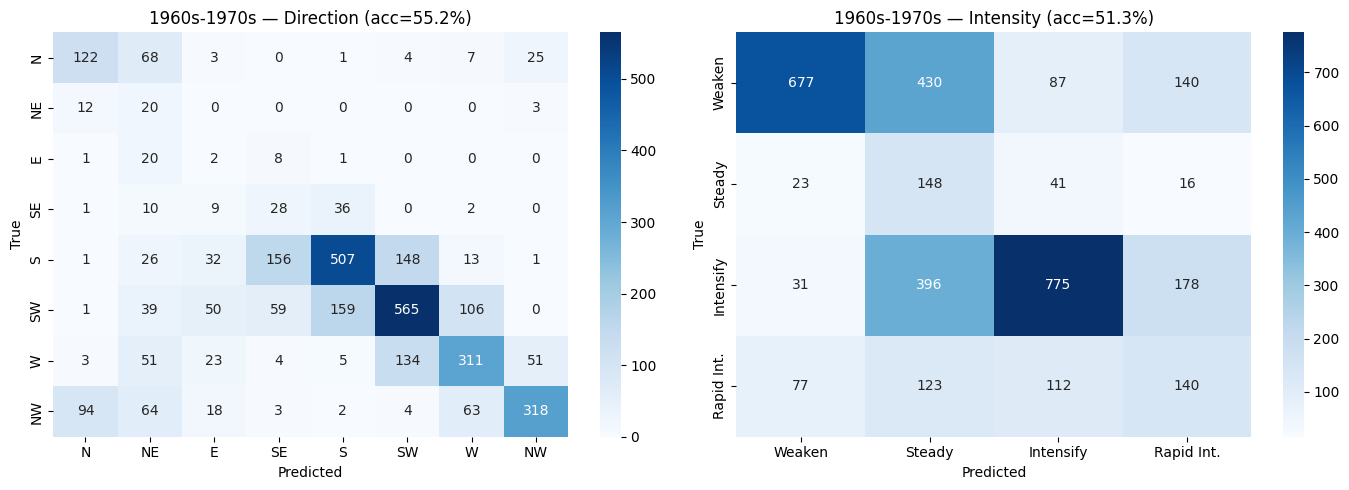

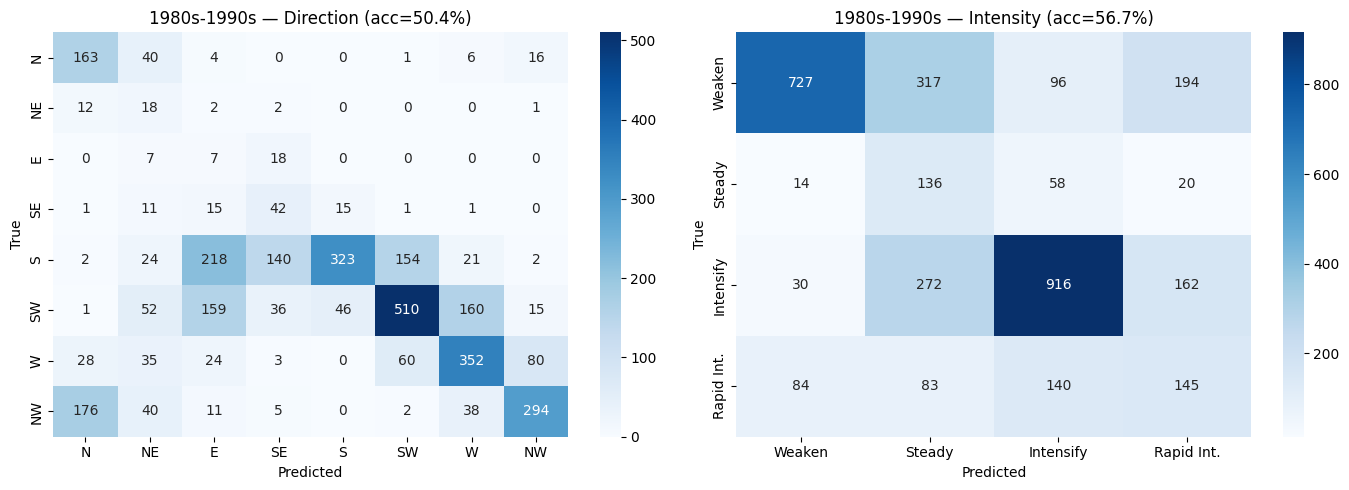

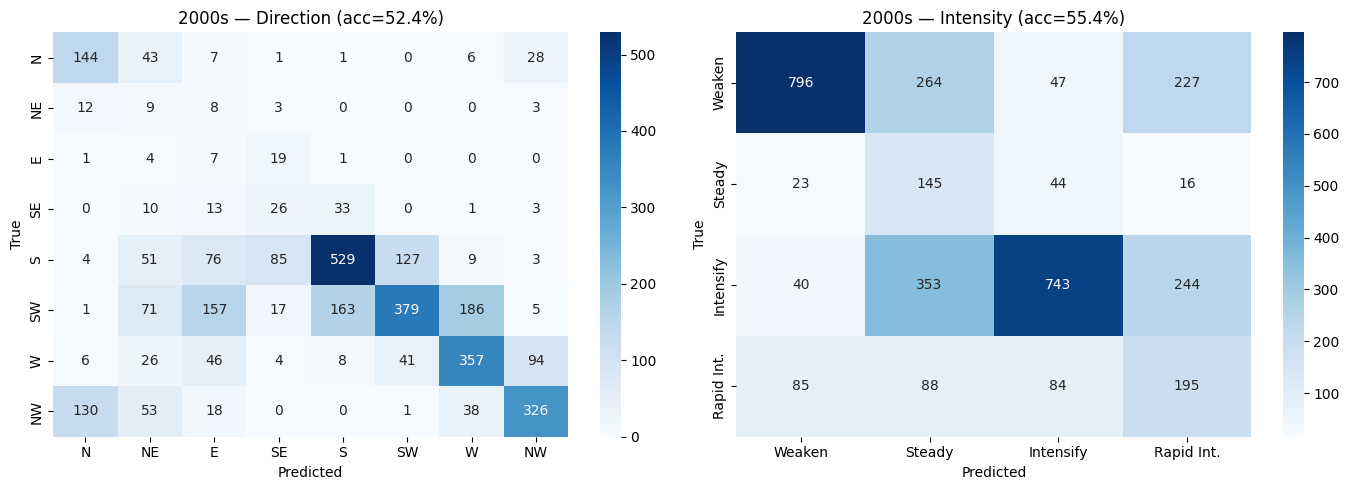

In [22]:
# ── Confusion matrices per decade model ──
if decade_eval:
    for label, res in decade_eval.items():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Direction confusion matrix
        cm_dir = confusion_matrix(res['dir_labels'], res['dir_preds'], labels=range(8))
        sns.heatmap(cm_dir, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=DIR_LABELS, yticklabels=DIR_LABELS)
        ax1.set_title(f'{label} — Direction (acc={res["dir_acc"]:.1%})')
        ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
        
        # Intensity confusion matrix
        cm_int = confusion_matrix(res['int_labels'], res['int_preds'], labels=range(4))
        sns.heatmap(cm_int, annot=True, fmt='d', cmap='Blues', ax=ax2,
                    xticklabels=INT_LABELS, yticklabels=INT_LABELS)
        ax2.set_title(f'{label} — Intensity (acc={res["int_acc"]:.1%})')
        ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
        
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, f'decade_{label.replace("-","_")}_cm.png'), dpi=150)
        plt.show()

In [24]:
# ── Per-class metrics (Precision / Recall / F1) per decade model ──
def per_class_metrics(y_true, y_pred, class_names):
    n = len(class_names)
    rows = []
    for c in range(n):
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == c and p == c)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != c and p == c)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == c and p != c)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        support = sum(1 for t in y_true if t == c)
        rows.append({'class': class_names[c], 'precision': prec,
                     'recall': rec, 'f1': f1, 'support': support})
    return pd.DataFrame(rows)

DIR_LABELS = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
INT_LABELS = ['Weaken', 'Steady', 'Intensify', 'Rapid Int.']

for label, res in decade_eval.items():
    print(f'\n{"="*60}')
    print(f'{label} — Direction')
    print(f'{"="*60}')
    display(per_class_metrics(res['dir_labels'], res['dir_preds'], DIR_LABELS))
    
    print(f'\n{label} — Intensity')
    display(per_class_metrics(res['int_labels'], res['int_preds'], INT_LABELS))

# ── Compare Rapid Intensification recall across decades ──
print(f'\n{"="*60}')
print('Rapid Intensification Recall Comparison')
print(f'{"="*60}')
print(f'{"Era":<20} {"Rapid Int. Recall":>20} {"Intensify Recall":>20}')
print('-' * 62)
for label, res in decade_eval.items():
    int_metrics = per_class_metrics(res['int_labels'], res['int_preds'], INT_LABELS)
    rapid_recall = int_metrics[int_metrics['class'] == 'Rapid Int.']['recall'].values[0]
    intens_recall = int_metrics[int_metrics['class'] == 'Intensify']['recall'].values[0]
    print(f'{label:<20} {rapid_recall:>20.1%} {intens_recall:>20.1%}')



1960s-1970s — Direction


,class,precision,recall,f1,support
0,N,0.519149,0.530435,0.524731,230
1,NE,0.067114,0.571429,0.120120,35
2,E,0.014599,0.062500,0.023669,32
3,SE,0.108527,0.325581,0.162791,86
4,S,0.713080,0.573529,0.635737,884
5,SW,0.660819,0.577120,0.616140,979
6,W,0.619522,0.534364,0.573801,582
7,NW,0.798995,0.561837,0.659751,566



1960s-1970s — Intensity


,class,precision,recall,f1,support
0,Weaken,0.837871,0.507496,0.632120,1334
1,Steady,0.134913,0.649123,0.223396,228
2,Intensify,0.763547,0.561594,0.647182,1380
3,Rapid Int.,0.295359,0.309735,0.302376,452



1980s-1990s — Direction


...


2000s — Direction


,class,precision,recall,f1,support
0,N,0.483221,0.626087,0.545455,230
1,NE,0.033708,0.257143,0.059603,35
2,E,0.021084,0.218750,0.038462,32
3,SE,0.167742,0.302326,0.215768,86
4,S,0.719728,0.598416,0.653490,884
5,SW,0.691606,0.387130,0.496398,979
6,W,0.597990,0.613402,0.605598,582
7,NW,0.705628,0.575972,0.634241,566



2000s — Intensity


,class,precision,recall,f1,support
0,Weaken,0.843220,0.596702,0.698859,1334
1,Steady,0.170588,0.635965,0.269017,228
2,Intensify,0.809368,0.538406,0.646649,1380
3,Rapid Int.,0.285924,0.431416,0.343915,452



Rapid Intensification Recall Comparison
Era                     Rapid Int. Recall     Intensify Recall
--------------------------------------------------------------
1960s-1970s                         31.0%                56.2%
1980s-1990s                         32.1%                66.4%
2000s                               43.1%                53.8%


### Interpretation — Climate Change Signal

The most notable trend is in **Rapid Intensification recall**: models trained on
more recent decades (2000s: 43.1%) detect modern rapid intensification events
significantly better than those trained on earlier eras (1960s: 31.0%).

This is consistent with the hypothesis that tropical cyclone intensification
behaviour has shifted over time — warmer sea surface temperatures in recent
decades may produce rapid intensification patterns that older climate regimes
did not exhibit, making 1960s-trained models poorly equipped to recognise them.

However, overall intensity accuracy differences across decades are modest,
and the general Intensify class does not show the same monotonic trend,
suggesting the climate signal is strongest in the most extreme intensification events.

### Per-Storm Analysis — Does each storm experience RI?

The per-timestep analysis above can be skewed by long-lived weakening storms contributing many samples.
Here we ask a cleaner question: **what proportion of storms in each decade experienced at least one
Rapid Intensification timestep?**

### WP Storm Power Analysis — Saffir-Simpson Distribution & ACE Trends

Using the raw Data_1d tracks to examine whether Western Pacific storms are getting stronger over time.
We classify each storm by its peak Saffir-Simpson category and compute Accumulated Cyclone Energy (ACE).

Total storms: 1799
Decades: ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

Storm peak category distribution:
peak_category
TD        25
TS       603
Cat 1    412
Cat 2    177
Cat 3    256
Cat 4    190
Cat 5    136


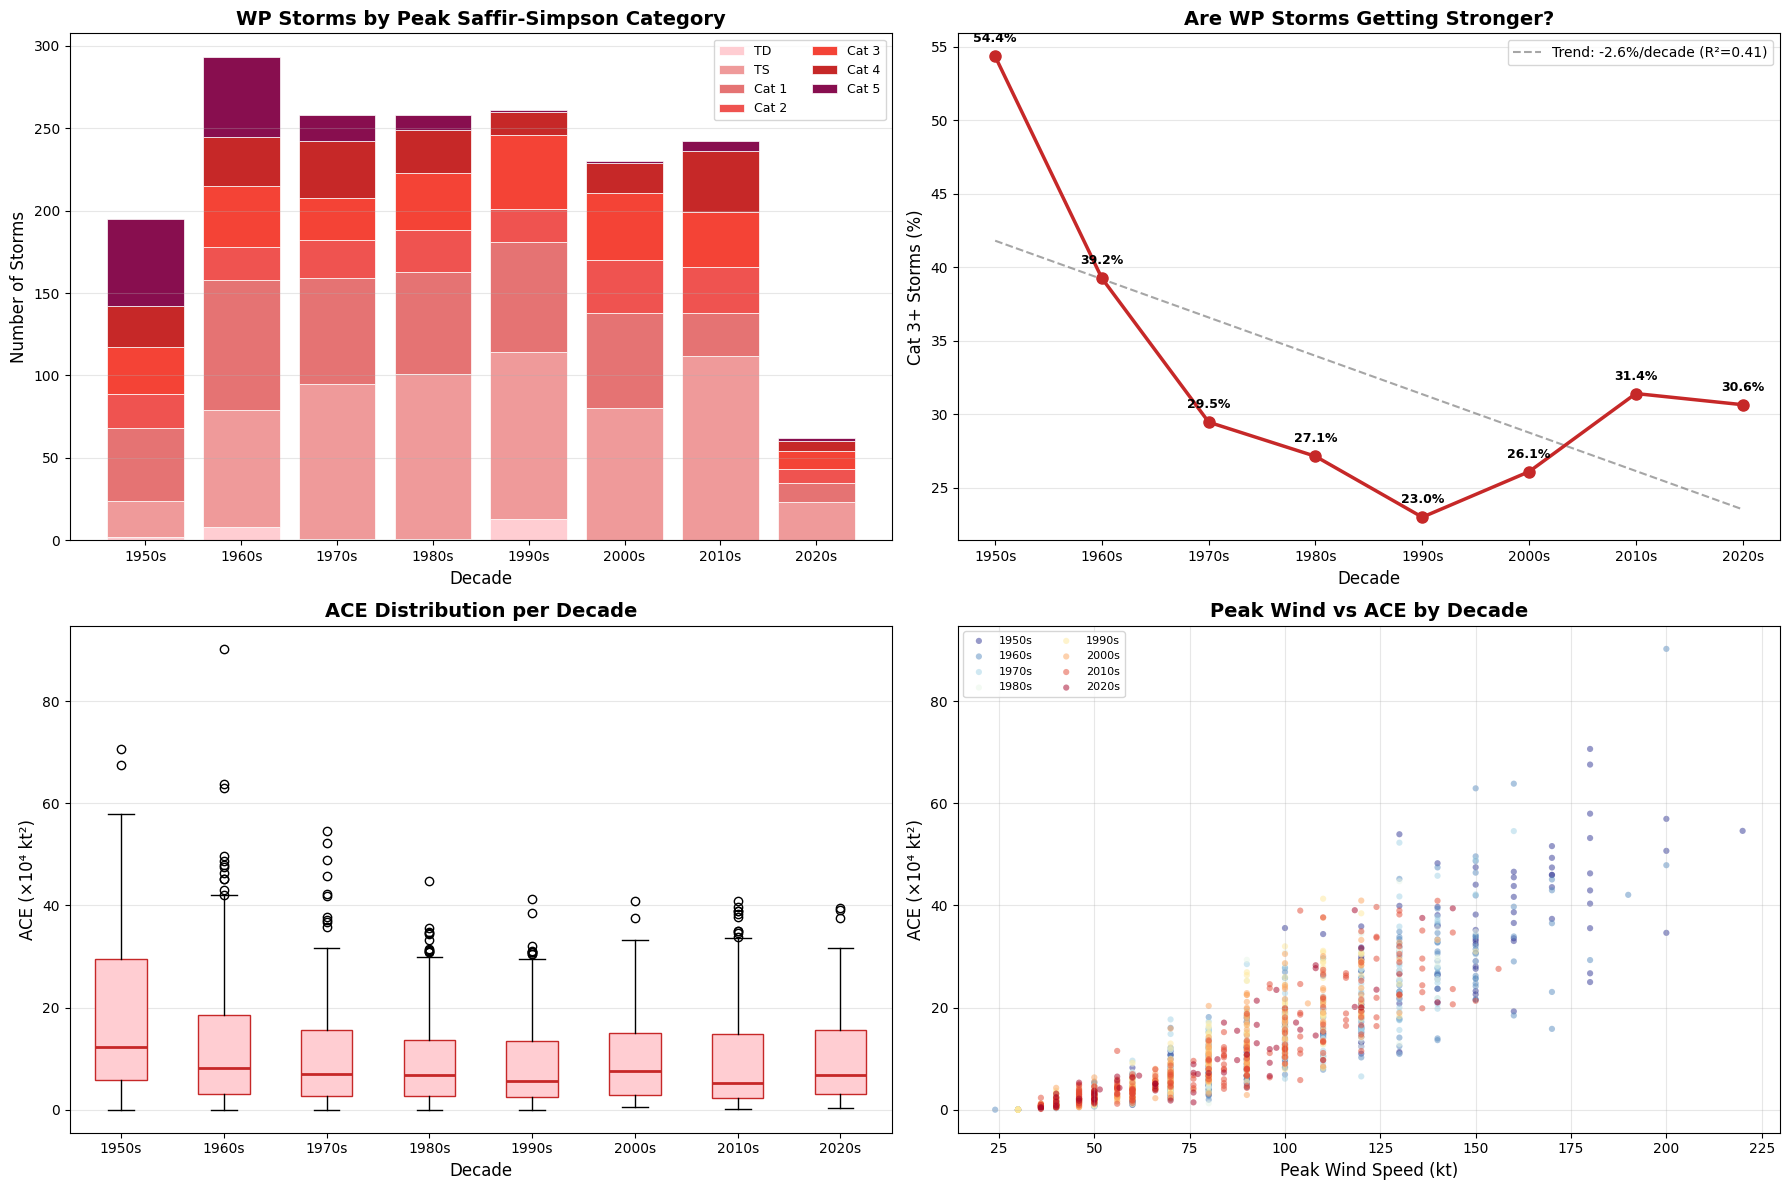


WP Storm Power — Decade Summary
Decade       Storms    Cat3+    Cat4+    Cat3+ %   Mean ACE    Total ACE  Mean Peak
------------------------------------------------------------------------------------------
1950s           195      106       78      54.4%       18.5       3615.9      107.7
1960s           293      115       78      39.2%       13.3       3894.0       90.7
1970s           258       76       50      29.5%       10.6       2726.4       81.0
1980s           258       70       35      27.1%        9.8       2535.0       78.1
1990s           261       60       15      23.0%        8.9       2328.3       71.9
2000s           230       60       19      26.1%       10.0       2301.8       76.5
2010s           242       76       43      31.4%        9.8       2375.7       76.8
2020s            62       19        8      30.6%       10.5        652.0       77.8

Trend: Cat 3+ proportion slope = -2.61%/decade (p=0.087)
→ Trend not statistically significant at p<0.05.


In [23]:
# ── Step 1: Build consolidated df_1d from all Data_1d track files ──

import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

all_rows = []
for split in ['train', 'val', 'test']:
    path = os.path.join(PATH_1D, AREA, split)
    for f in sorted(glob.glob(os.path.join(path, '*.txt'))):
        df = pd.read_csv(f, delimiter='\t', header=None,
                         names=['ID', 'FLAG', 'LON', 'LAT', 'P', 'W', 'TIME', 'Name'])
        fname = os.path.splitext(os.path.basename(f))[0]
        year = int(fname[2:6])  # skip basin prefix e.g. WP1950...
        df['basin'] = AREA
        df['year'] = year
        df['storm_name'] = fname
        df['split'] = split
        df['storm_id'] = f'{AREA}_{fname}'
        all_rows.append(df)

df_1d = pd.concat(all_rows, ignore_index=True)

# Step 1 — Denormalise wind speed
# Data_1d W is normalised as: W = (wind_kt - 80) / 50
# Verified by cross-referencing with Env-Data wind values
df_1d['wind_kt'] = df_1d['W'] * 50 + 80

# Step 2 — Saffir-Simpson category per timestep
def saffir_simpson(wind_kt):
    if wind_kt < 34:   return 'TD'
    if wind_kt < 64:   return 'TS'
    if wind_kt < 83:   return 'Cat 1'
    if wind_kt < 96:   return 'Cat 2'
    if wind_kt < 113:  return 'Cat 3'
    if wind_kt < 137:  return 'Cat 4'
    return 'Cat 5'

df_1d['ss_category'] = df_1d['wind_kt'].apply(saffir_simpson)

# Step 3 — Peak category per storm
storm_peak = df_1d.groupby('storm_id').agg(
    basin=('basin', 'first'),
    year=('year', 'first'),
    peak_wind_kt=('wind_kt', 'max'),
).reset_index()
storm_peak['peak_category'] = storm_peak['peak_wind_kt'].apply(saffir_simpson)

# Step 4 — ACE per storm (sum of wind_kt² at 6-hourly steps where wind_kt >= 34, / 10000)
ace_per_storm = (
    df_1d[df_1d['wind_kt'] >= 34]
    .groupby('storm_id')['wind_kt']
    .apply(lambda x: (x ** 2).sum() / 1e4)
    .reset_index()
    .rename(columns={'wind_kt': 'ACE'})
)
storm_peak = storm_peak.merge(ace_per_storm, on='storm_id', how='left')
storm_peak['ACE'] = storm_peak['ACE'].fillna(0)

# Step 5 — Decade statistics (WP only)
cat_order = ['TD', 'TS', 'Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']
storm_peak['decade'] = (storm_peak['year'] // 10 * 10).astype(str) + 's'
storm_peak['is_cat3plus'] = storm_peak['peak_category'].isin(['Cat 3', 'Cat 4', 'Cat 5'])
storm_peak['is_cat4plus'] = storm_peak['peak_category'].isin(['Cat 4', 'Cat 5'])

decade_stats = storm_peak.groupby('decade').agg(
    total_storms=('storm_id', 'count'),
    cat3plus=('is_cat3plus', 'sum'),
    cat4plus=('is_cat4plus', 'sum'),
    mean_ACE=('ACE', 'mean'),
    total_ACE=('ACE', 'sum'),
    mean_peak_wind=('peak_wind_kt', 'mean'),
).reset_index()
decade_stats['cat3plus_pct'] = decade_stats['cat3plus'] / decade_stats['total_storms'] * 100

print(f'Total storms: {len(storm_peak)}')
print(f'Decades: {sorted(storm_peak["decade"].unique())}')
print(f'\nStorm peak category distribution:')
print(storm_peak['peak_category'].value_counts().reindex(cat_order).to_string())

# ── Step 6: Four-panel plot ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Colour ramp: light (TD) to dark red (Cat 5)
cat_colors = {
    'TD':    '#FFCDD2',
    'TS':    '#EF9A9A',
    'Cat 1': '#E57373',
    'Cat 2': '#EF5350',
    'Cat 3': '#F44336',
    'Cat 4': '#C62828',
    'Cat 5': '#880E4F',
}

# Plot A: Stacked bar — storms per decade by peak category
decades_sorted = sorted(storm_peak['decade'].unique())
cat_counts = pd.crosstab(storm_peak['decade'], storm_peak['peak_category']).reindex(
    index=decades_sorted, columns=cat_order, fill_value=0)

bottom = np.zeros(len(decades_sorted))
for cat in cat_order:
    vals = cat_counts[cat].values
    axes[0, 0].bar(decades_sorted, vals, bottom=bottom, color=cat_colors[cat],
                   label=cat, edgecolor='white', linewidth=0.5)
    bottom += vals

axes[0, 0].set_title('WP Storms by Peak Saffir-Simpson Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Decade', fontsize=12)
axes[0, 0].set_ylabel('Number of Storms', fontsize=12)
axes[0, 0].legend(loc='upper right', fontsize=9, ncol=2)
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot B: Cat 3+ proportion trend with linear regression
ds = decade_stats.sort_values('decade')
x_num = np.arange(len(ds))
y_val = ds['cat3plus_pct'].values

axes[0, 1].plot(ds['decade'], y_val, 'o-', color='#C62828', linewidth=2.5, markersize=8, zorder=3)

# Linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(x_num, y_val)
trend_line = intercept + slope * x_num
axes[0, 1].plot(ds['decade'], trend_line, '--', color='grey', linewidth=1.5, alpha=0.7,
                label=f'Trend: {slope:+.1f}%/decade (R²={r_value**2:.2f})')

for i, (d, v) in enumerate(zip(ds['decade'], y_val)):
    axes[0, 1].annotate(f'{v:.1f}%', (d, v), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

axes[0, 1].set_title('Are WP Storms Getting Stronger?', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Decade', fontsize=12)
axes[0, 1].set_ylabel('Cat 3+ Storms (%)', fontsize=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot C: ACE box plot per decade
ace_data = [storm_peak[storm_peak['decade'] == d]['ACE'].values for d in decades_sorted]
bp = axes[1, 0].boxplot(ace_data, labels=decades_sorted, patch_artist=True,
                        medianprops=dict(color='#C62828', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#FFCDD2')
    patch.set_edgecolor('#C62828')

axes[1, 0].set_title('ACE Distribution per Decade', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Decade', fontsize=12)
axes[1, 0].set_ylabel('ACE (×10⁴ kt²)', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot D: Scatter — peak wind vs ACE, coloured by decade
decade_cmap = plt.cm.RdYlBu_r
unique_decades = sorted(storm_peak['decade'].unique())
norm = plt.Normalize(0, len(unique_decades) - 1)

for i, d in enumerate(unique_decades):
    subset = storm_peak[storm_peak['decade'] == d]
    axes[1, 1].scatter(subset['peak_wind_kt'], subset['ACE'],
                       c=[decade_cmap(norm(i))], label=d, alpha=0.5, s=20, edgecolors='none')

axes[1, 1].set_title('Peak Wind vs ACE by Decade', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Peak Wind Speed (kt)', fontsize=12)
axes[1, 1].set_ylabel('ACE (×10⁴ kt²)', fontsize=12)
axes[1, 1].legend(fontsize=8, ncol=2, loc='upper left')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wp_storm_power_analysis.png'), dpi=200, bbox_inches='tight')
plt.show()

# ── Step 7: Summary table ──
print('\n' + '=' * 90)
print('WP Storm Power — Decade Summary')
print('=' * 90)
print(f'{"Decade":<10} {"Storms":>8} {"Cat3+":>8} {"Cat4+":>8} {"Cat3+ %":>10} {"Mean ACE":>10} {"Total ACE":>12} {"Mean Peak":>10}')
print('-' * 90)
for _, row in ds.iterrows():
    print(f'{row["decade"]:<10} {row["total_storms"]:>8.0f} {row["cat3plus"]:>8.0f} {row["cat4plus"]:>8.0f} '
          f'{row["cat3plus_pct"]:>9.1f}% {row["mean_ACE"]:>10.1f} {row["total_ACE"]:>12.1f} {row["mean_peak_wind"]:>10.1f}')

print(f'\nTrend: Cat 3+ proportion slope = {slope:+.2f}%/decade (p={p_value:.3f})')
if p_value < 0.05:
    print('→ Statistically significant trend detected.')
else:
    print('→ Trend not statistically significant at p<0.05.')